In [1]:
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from simpleml.linear_models import LinearRegression
model = LinearRegression()

In [5]:
area_train = np.linspace(10, 100, 100)

area_test = np.linspace(10, 100, 20)

price_train = 10 * area_train + np.random.normal(0, 20, size=area_train.shape)

price_test = 10 * area_test + np.random.normal(0, 35, size=area_test.shape)

reg = model.fit(area_train, price_train)


Early Stopping


In [7]:
y_pred = reg.predict(area_test)

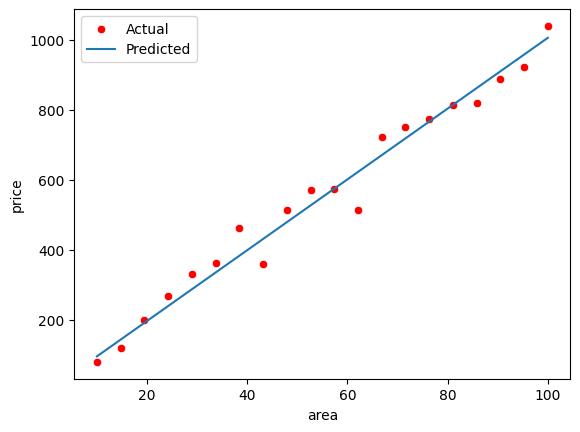

In [9]:

sns.scatterplot(x="area", y="price", data = pd.DataFrame({"area": area_test, "price": price_test}), color="red", label = "Actual")


line = plt.plot(area_test, y_pred, label = "Predicted")


plt.legend()
plt.show()

In [11]:
from simpleml.metrics import regression_report
r2 = regression_report(price_test, y_pred)
r2

{'R2 Score': 0.9738,
 'Mean Squared Error': 1952.2087,
 'Mean Absolute Error': 35.5686,
 'Root Mean Squared Error': 44.1838,
 'Mean Absolute Percentage Error': 8.7043}

In [57]:
def gradient_descent(b, db, alpha):
    return b - alpha * db

In [8]:
def adaptive_gradient(b, db, G, alpha):
    epsilon = 1 * 10**(-8)
    step = alpha / (G ** .5 + epsilon)
    return b - step * db

In [9]:
def Simple_Linear_Regression(X, y):
    b0 = random.random()
    b1 = random.random()
    X_scaled = Z_score_standardization(X)
    y_pred = b0 + b1*X_scaled
    return X_scaled, y, b0, b1

In [1]:
def fit(model, alpha=0.01, itterations=1000, show_loss=False, loss_iteration=100, optimizer="gradient_descent"):
    X = model[0]
    y = model[1]
    b0 = model[2]
    b1 = model[3]
    n = len(X)
    old_loss = math.inf
    loss_count = 0
    G0 = 0
    G1 = 0
    LOSS = []
    for i in range(itterations):
        y_pred = b0 + b1*X
        db0 = (2/n) * (y_pred - y).sum()
        db1 = (2/n) * ((y_pred - y) * X).sum()

        #trial step
        if optimizer == "gradient_descent":
            b0_t = gradient_descent(b0, db0, alpha)
            b1_t = gradient_descent(b1, db1, alpha)
        elif optimizer == "adaptive_gradient":
            G0 += db0 ** 2
            G1 += db1 ** 2
            b0_t = adaptive_gradient(b0, db0, G0, alpha)
            b1_t = adaptive_gradient(b1, db1, G1, alpha)
        else:
            raise ValueError(f"No optimizer with name {optimizer} found")
        

        y_pred_t = b0_t + b1_t*X
        new_loss = loss(y, y_pred_t)
        
        if old_loss < new_loss:
            print(f"Stopping early at iteration {i}, loss increased to {new_loss}")
            break
            
        b0 = b0_t
        b1 = b1_t
        old_loss = new_loss
        loss_count += 1
        LOSS.append(new_loss)
        if show_loss and loss_count % loss_iteration == 0:
            print(f"- epoch {loss_count}, loss = {new_loss}")
        
   
    return {"b0": b0, "b1": b1, "loss": np.array(LOSS)}

In [11]:
def predict(fitted_model, X):
    predictions = []
    for i in X:
        predictions.append(fitted_model["b0"] + fitted_model["b1"] * (i - X.mean()) / X.std())
    return pd.Series(predictions)
    

In [152]:
area_train = np.linspace(10, 100, 1000)

area_test = np.linspace(10, 100, 200)

price_train = 10 * area_train + np.random.normal(0, 20, size=area_train.shape)

price_test = 10 * area_test + np.random.normal(0, 35, size=area_test.shape)

model = Simple_Linear_Regression(area_train, price_train)

predictions = pd.DataFrame(columns=("Optimizer", "Predictions", "Loss", "Final Loss"))


NameError: name 'Simple_Linear_Regression' is not defined

In [111]:
#Gradient Descent
fitted = fit(model, alpha=0.1,itterations=1000, show_loss=True, loss_iteration = 1000, optimizer="gradient_descent")
y_pred_gcd = predict(fitted, area_test)


Stopping early at iteration 102, loss increased to 406.70662336522616


In [113]:
fitted = fit(model, alpha=10,itterations=100000, show_loss=True, loss_iteration = 1000, optimizer="adaptive_gradient")
y_pred_adagrad = predict(fitted, area_test)


- epoch 1000, loss = 9974.726655991637
- epoch 2000, loss = 1148.9244975732138
- epoch 3000, loss = 465.7862525906609
- epoch 4000, loss = 411.41863859776663
- epoch 5000, loss = 407.08249906092027
- epoch 6000, loss = 406.73660720704476
- epoch 7000, loss = 406.70901519764413
- epoch 8000, loss = 406.7068141634171
- epoch 9000, loss = 406.7066385853351
- epoch 10000, loss = 406.70662457934526
- epoch 11000, loss = 406.70662346207735
- epoch 12000, loss = 406.7066233729521
- epoch 13000, loss = 406.7066233658424
- epoch 14000, loss = 406.70662336527533
Stopping early at iteration 14329, loss increased to 406.7066233652476


In [107]:
predictions.head()

,Optimizer,Predictions,Loss,Final Loss
0,Gradient Descent,0 100.439802 1 104.953680 2 109...,"[236407.33481925406, 151447.1086687341, 97072....",97072.563932
1,Adaptive Gradient,0 100.439797 1 104.953675 2 109...,"[353181.13828281284, 342262.92434867, 333560.3...",333560.369083


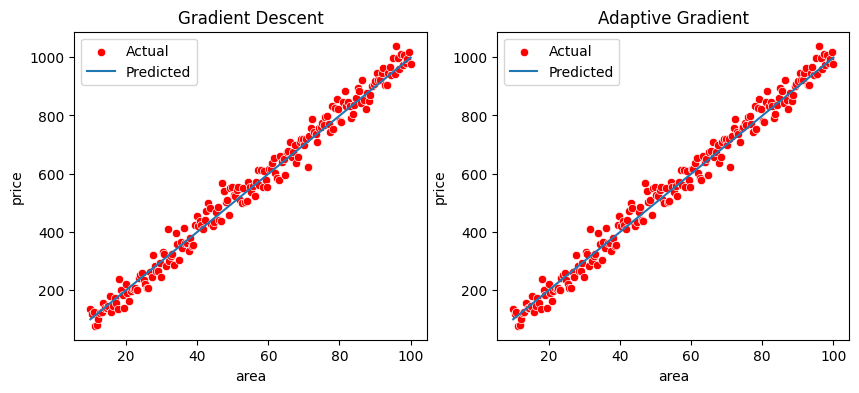

In [131]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
sns.scatterplot(x="area", y="price", data = pd.DataFrame({"area": area_test, "price": price_test}), color="red", label = "Actual", ax=axes[0])
sns.scatterplot(x="area", y="price", data = pd.DataFrame({"area": area_test, "price": price_test}), color="red", label = "Actual", ax=axes[1])

line = axes[0].plot(area_test, y_pred_gcd, label = "Predicted")
line = axes[1].plot(area_test, y_pred_adagrad, label = "Predicted")

axes[0].set_title("Gradient Descent")
axes[1].set_title("Adaptive Gradient")

axes[0].legend()
axes[1].legend()

## Simple Linear Regression is implemented
### However there's still some to do things to improve apon it
### 1. Change from gradient descent optimization to adaptive varient possibly AdaGrad
### 2. Clean up the code 
### 3. Early stopping based on MSE (Done)
### 3. Implement Multiple Linear Regression
### 4. Regularization Techniques??

#### It seems I am reaching the limit with vanilla gradient descent with this few data points if I want a better model with similar layout I need more data points ALOT more & possibly some of the improvements above might help

In [277]:
x = np.array(((1,1), (1,2),(3,4)))
y = np.array((0,1,2))
z = 0
for i in range(len(y)):
    z += y[i] * x[i] 

print(z)

[ 7 10]


In [363]:
x = np.array((1,2,3,4))
z = np.vstack([(1,1,1,1),x])
z.shape[0]

2

In [590]:
from sklearn.linear_model import LinearRegression

df = pd.DataFrame({"area":area_test,"price":price_test})
X = df[["area"]]
y = df["price"]
m = LinearRegression()
m.fit(X, y)
m.coef_

array([9.70804698])